In [1]:
folder = './image_no_lung'
target_label = ['Covid','Normal','Viral_Pneumonia']

In [2]:
from torchvision.datasets import ImageFolder
from torchvision import transforms

dataset = ImageFolder(folder, transform=transforms.ToTensor())
print('Data size: ',len(dataset))
dataset.classes

Data size:  15153


['Covid', 'Normal', 'Viral_Pneumonia']

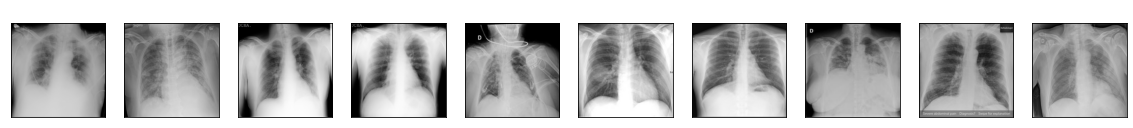

In [3]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20,20))

for i in range(10):
    image, label = dataset[i]
    ax = fig.add_subplot(1, 10, i+1, xticks=[], yticks = [])
    ax.imshow(image.permute(1,2,0))
    ax.set_title(target_label[label], color='white')

In [4]:
import pandas as pd
import numpy as np

count = {}

for i in range(len(dataset)):
    _, labels = dataset[i]
    label = target_label[labels]
    if label not in count:
        count[label] = 1
    elif label in count:
        count[label] += 1

df = pd.DataFrame(count, index=np.arange(1))
df = df.transpose().reset_index()
df.columns = ['Sympton', 'count']
df

,Sympton,count
0,Covid,3616
1,Normal,10192
2,Viral_Pneumonia,1345


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

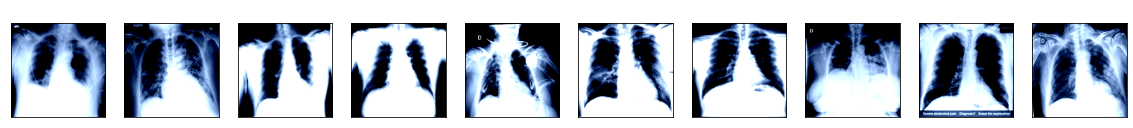

In [5]:
data_transform = transforms.Compose([transforms.Resize((224, 224)), 
                                     transforms.ToTensor(),
                                     transforms.Normalize(mean = [0.485, 0.456, 0.406],std = [0.229, 0.224, 0.225])])
load_data = ImageFolder(folder, transform=data_transform)

fig = plt.figure(figsize=(20, 10))
for i in range(10):
    image, label = load_data[i]
    ax = fig.add_subplot(1, 10, i+1, xticks=[], yticks = [])
    ax.imshow(image.permute(1,2,0))
    ax.set_title(target_label[label], color='white');

In [6]:
from sklearn.model_selection import train_test_split

idx_label = {}

for i in range(len(dataset)):
    _, label = dataset[i]
    idx_label[i] = label
x_train, x_val, y_train, y_val = train_test_split(list(idx_label.keys()), list(idx_label.values()), 
                                                  stratify = list(idx_label.values()), test_size=0.05)

idx_label_2 = {}
for idx, label in idx_label.items():
    if idx not in x_val:
        idx_label_2[idx] = label

#split data train and test after exlude x_val
x_train, x_test, y_train, y_test = train_test_split(list(idx_label_2.keys()), list(idx_label_2.values()),
                                                    stratify = list(idx_label_2.values()), test_size=0.05)


print(len(x_train))
print(len(x_val))
print(len(x_test))

13675
758
720


In [7]:
from collections import Counter

def plot_dist(indexes, dataset=dataset):
    count = Counter()
    for i in indexes:
        _, label = dataset[i]
        count[target_label[label]] += 1
        
    dist_2 = dict(sorted(count.items(), key=lambda kv: kv[1], reverse=True))
    plt.bar(dist_2.keys(), dist_2.values())
    plt.xticks(rotation=30)
    plt.title('Data distribution'); plt.ylabel('count')
    plt.show()

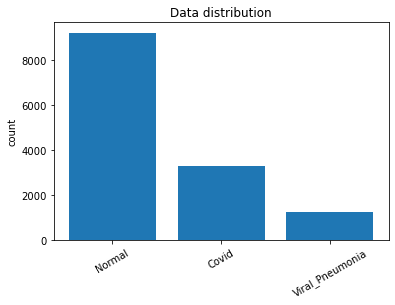

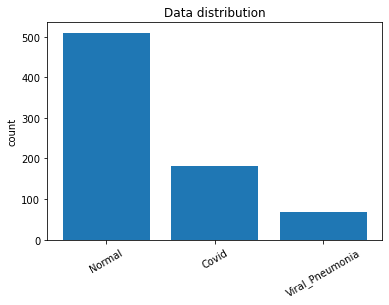

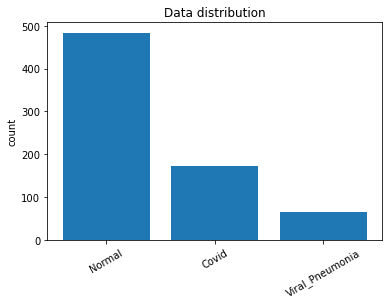

In [8]:
plot_dist(x_train)
plot_dist(x_val)
plot_dist(x_test)


In [9]:
from torch.utils.data import DataLoader, SubsetRandomSampler
    
train_set = SubsetRandomSampler(x_train)
val_set = SubsetRandomSampler(x_val)
test_set = SubsetRandomSampler(x_test)

train_loader = DataLoader(load_data, batch_size=32, 
                          num_workers=4, sampler= train_set)
val_loader = DataLoader(load_data, batch_size=32,  
                        num_workers=4, sampler=val_set)
test_loader = DataLoader(load_data, batch_size = 32,
                          num_workers=4, sampler=test_set)

In [10]:
import torchvision

torchvision.__version__

'0.12.0a0'

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
import time


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [13]:
model = models.resnet34(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3)

model1 = models.densenet121(pretrained=True)
model1.classifier = nn.Linear(1024, 3)

model = model.to(device)
model1 = model1.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)


In [ ]:
num_epochs = 4
start_time = time.time()

for epoch in range(num_epochs):

    print('Epoch:', str(epoch+1) + '/' + str(num_epochs))
    print('-'*10)

    for phase in ['train', 'val']:

        running_loss = 0.
        running_corrects = 0
        
        if phase == 'train':

            model.train()

            for inputs, labels in train_loader:

                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()
                outputs = model(inputs)

                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(train_set)
            epoch_acc = running_corrects / len(train_set) * 100.

            print(phase,'|' , ' Loss: {:.4f}  / Train Acc: {:.4f}%'.format(epoch_loss,epoch_acc))

        if phase == 'val':

            model.eval()

            for inputs, labels in val_loader:

                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(val_set)
            epoch_acc = running_corrects / len(val_set) * 100.

            print(phase ,'|', ' Loss: {:.4f}  / Acc: {:.4f}%'.format(epoch_loss,epoch_acc))

    print('Time:'+ str(int(time.time() - start_time)//60)+'분'+str(int(time.time() - start_time)%60)+'초')
    print('-'*10)


Epoch: 1/4
----------
train |  Loss: 0.2700  / Train Acc: 89.9671%
val |  Loss: 0.2086  / Acc: 91.5567%
Time:18분26초
----------
Epoch: 2/4
----------
train |  Loss: 0.1367  / Train Acc: 95.1298%
val |  Loss: 0.0826  / Acc: 97.0976%
Time:561분54초
----------
Epoch: 3/4
----------
train |  Loss: 0.1038  / Train Acc: 96.4973%
val |  Loss: 0.0703  / Acc: 97.3615%
Time:579분46초
----------
Epoch: 4/4
----------
train |  Loss: 0.0858  / Train Acc: 97.1042%
val |  Loss: 0.0913  / Acc: 96.8338%
Time:597분31초
----------


In [22]:
torch.save(model, 'resnet34_no_lung.pt')

In [20]:
def showtime(input, title):

    input = input.numpy().transpose((1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    input = std * input + mean
    input = np.clip(input, 0, 1)

    plt.imshow(input)
    plt.title(title)
    plt.show()

[예측 결과: Normal] (실제 정답: Normal)


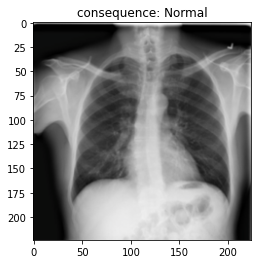

[예측 결과: Normal] (실제 정답: Normal)


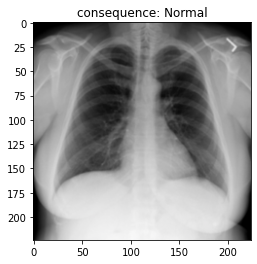

[예측 결과: Normal] (실제 정답: Normal)


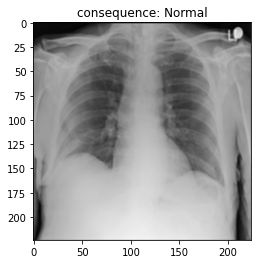

[예측 결과: Normal] (실제 정답: Normal)


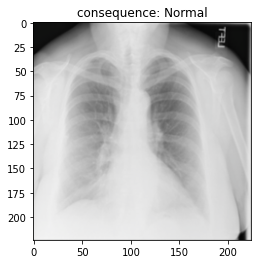

[예측 결과: Normal] (실제 정답: Normal)


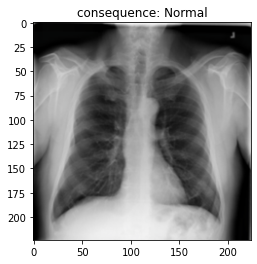

[예측 결과: Covid] (실제 정답: Covid)


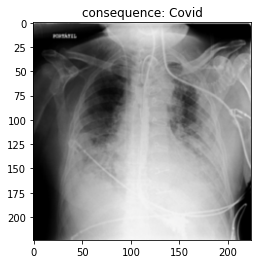

[예측 결과: Covid] (실제 정답: Covid)


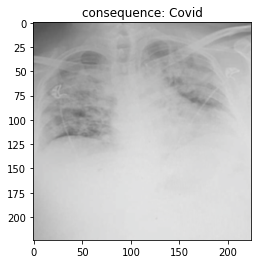

[예측 결과: Normal] (실제 정답: Normal)


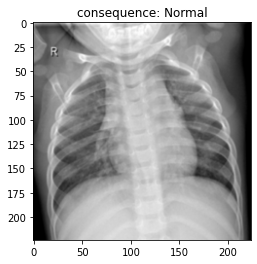

[예측 결과: Normal] (실제 정답: Normal)


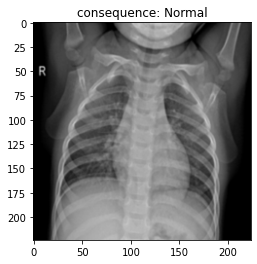

[예측 결과: Normal] (실제 정답: Normal)


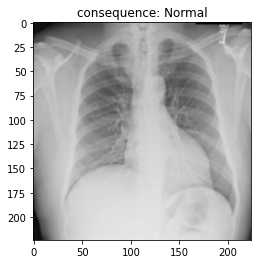

[예측 결과: Covid] (실제 정답: Covid)


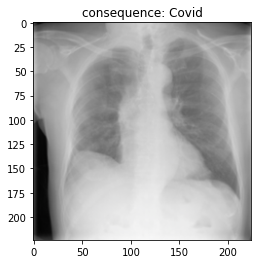

[예측 결과: Normal] (실제 정답: Normal)


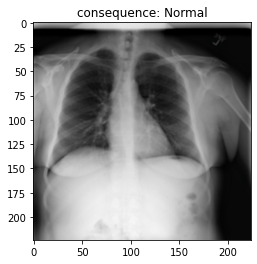

[예측 결과: Normal] (실제 정답: Normal)


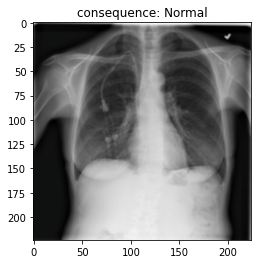

[예측 결과: Normal] (실제 정답: Normal)


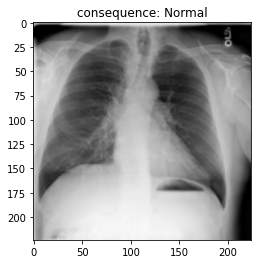

[예측 결과: Normal] (실제 정답: Normal)


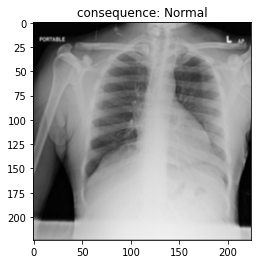

[예측 결과: Normal] (실제 정답: Normal)


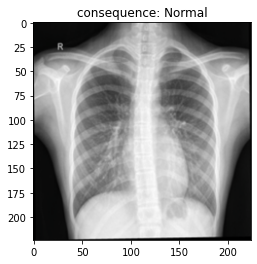

[예측 결과: Normal] (실제 정답: Normal)


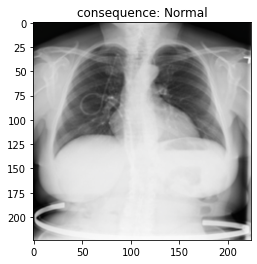

[예측 결과: Viral_Pneumonia] (실제 정답: Viral_Pneumonia)


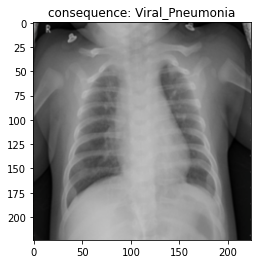

[예측 결과: Normal] (실제 정답: Normal)


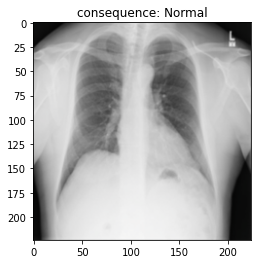

[예측 결과: Normal] (실제 정답: Normal)


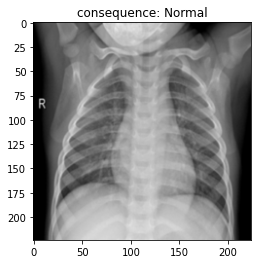

[예측 결과: Normal] (실제 정답: Normal)


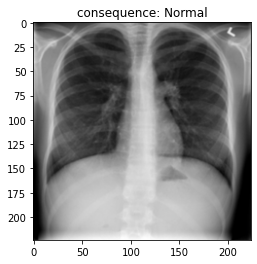

[예측 결과: Viral_Pneumonia] (실제 정답: Viral_Pneumonia)


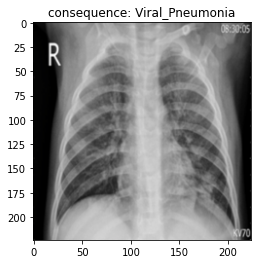

[예측 결과: Covid] (실제 정답: Covid)


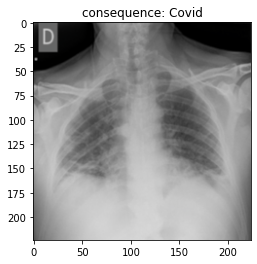

[Test Phase] Loss: 0.0422 Acc: 98.8889% Time: 45.7540s


In [21]:
from PIL import Image

model = torch.load('resnet34_no_lung.pt')
model.eval()
start_time = time.time()

with torch.no_grad():
    running_loss = 0.
    running_corrects = 0

    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

        print(f'[예측 결과: {target_label[preds[0]]}] (실제 정답: {target_label[labels.data[0]]})')
        showtime(inputs.cpu().data[0], title='consequence: ' + target_label[preds[0]])

    epoch_loss = running_loss / len(test_set)
    epoch_acc = running_corrects / len(test_set) * 100.
    print('[Test Phase] Loss: {:.4f} Acc: {:.4f}% Time: {:.4f}s'.format(epoch_loss, epoch_acc, time.time() - start_time))